# Smart Logistics Exploratory Data Analysis  
* Rahim Manji

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




data = pd.read_csv(
    '../data/smart_logistics_cleaned.csv',
    parse_dates=['Timestamp']
)

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Timestamp                1000 non-null   datetime64[ns]
 1   Asset_ID                 1000 non-null   object        
 2   Latitude                 1000 non-null   float64       
 3   Longitude                1000 non-null   float64       
 4   Inventory_Level          1000 non-null   int64         
 5   Shipment_Status          1000 non-null   object        
 6   Temperature              1000 non-null   float64       
 7   Humidity                 1000 non-null   float64       
 8   Traffic_Status           1000 non-null   object        
 9   Waiting_Time             1000 non-null   int64         
 10  User_Transaction_Amount  1000 non-null   int64         
 11  User_Purchase_Frequency  1000 non-null   int64         
 12  Logistics_Delay_Reason   1000 non-n

## 1. Overall Logistics Performance

- Evaluate the overall operational performance of the logistics system.
- Key performance indicators include shipment volume, logistics delay rate, waiting time, asset utilization, inventory levels, and forecast demand.

In [2]:
# Calculate  KPIs

In [4]:
# Overall logistics KPIs

total_shipments = len(data)

total_delays = data['Logistics_Delay'].sum()

delay_rate = data['Logistics_Delay'].mean() * 100

avg_waiting_time = data['Waiting_Time'].mean()

avg_asset_utilization = data['Asset_Utilization'].mean()

avg_inventory = data['Inventory_Level'].mean()

avg_demand = data['Demand_Forecast'].mean()

print(f"Total Shipments: {total_shipments:,}")
print(f"Total Delays: {total_delays:,}")
print(f"Delay Rate: {delay_rate:.1f}%")
print(f"Average Waiting Time: {avg_waiting_time:.1f}")
print(f"Average Asset Utilization: {avg_asset_utilization:.1f}%")
print(f"Average Inventory Level: {avg_inventory:.1f}")
print(f"Average Forecast Demand: {avg_demand:.1f}")

Total Shipments: 1,000
Total Delays: 566
Delay Rate: 56.6%
Average Waiting Time: 35.1
Average Asset Utilization: 79.6%
Average Inventory Level: 297.9
Average Forecast Demand: 199.3


### Observations  

> 56.6% delayed  (more than half)

> What operational conditions are associated with this high delay rate?


> Average inventory: 298  vs  Average demand:  199  (averages are misleading)


### Visualize
delay vs. no delay

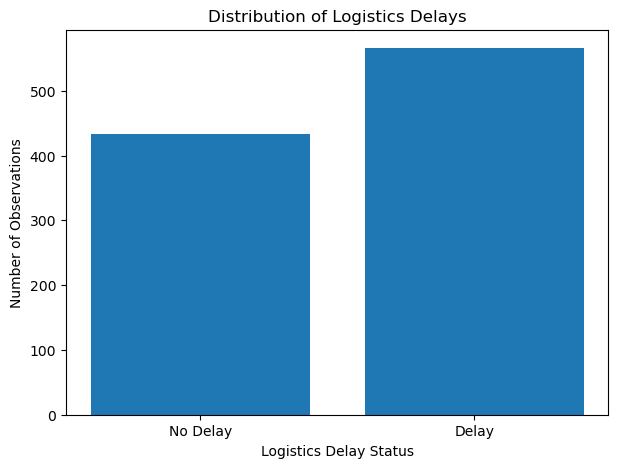

In [5]:
# Count logistics delays
delay_counts = data['Logistics_Delay'].value_counts().sort_index()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ['No Delay', 'Delay'],
    delay_counts.values
)

plt.title('Distribution of Logistics Delays')
plt.xlabel('Logistics Delay Status')
plt.ylabel('Number of Observations')

plt.show()

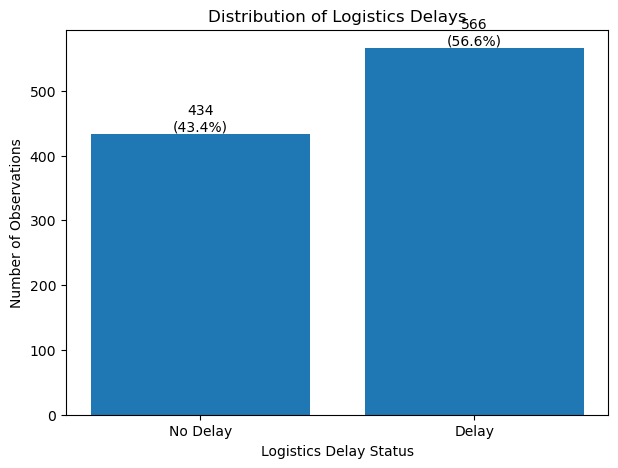

In [6]:
delay_counts = data['Logistics_Delay'].value_counts().sort_index()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ['No Delay', 'Delay'],
    delay_counts.values
)

plt.title('Distribution of Logistics Delays')
plt.xlabel('Logistics Delay Status')
plt.ylabel('Number of Observations')

for bar in bars:
    height = bar.get_height()
    percentage = height / len(data) * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height}\n({percentage:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.show()

### Observation: 
> The dataset contains 566 delayed observations (56.6%) and 434 non-delayed observations (43.4%).

> Delays represent the majority of recorded logistics activity.

> The class distribution is relatively balanced, but the high overall delay rate requires further investigation into traffic conditions, fleet performance, waiting time, utilization, and other operational factors

## 2. Fleet Performance Analysis

* Evaluate the performance of individual fleet assets to determine
whether certain trucks experience higher delay rates, waiting times, or asset
utilization than others.

In [7]:
# Calculate performance metrics for each truck

fleet_performance = (
    data.groupby('Asset_ID')
    .agg(
        Total_Shipments=('Logistics_Delay', 'size'),
        Total_Delays=('Logistics_Delay', 'sum'),
        Average_Waiting_Time=('Waiting_Time', 'mean'),
        Average_Utilization=('Asset_Utilization', 'mean')
    )
    .reset_index()
)

fleet_performance

,Asset_ID,Total_Shipments,Total_Delays,Average_Waiting_Time,Average_Utilization
0,Truck_1,89,46,37.022472,80.516854
1,Truck_10,105,68,32.295238,79.575238
2,Truck_2,105,56,35.238095,80.155238
3,Truck_3,93,58,36.860215,80.097849
4,Truck_4,107,63,35.308411,79.060748
5,Truck_5,93,46,34.494624,76.595699
6,Truck_6,103,54,35.611650,79.026214
7,Truck_7,102,60,36.725490,80.669608
8,Truck_8,109,62,33.366972,80.244954
9,Truck_9,94,53,34.159574,79.943617


In [8]:
data.Asset_ID.unique()

array(['Truck_7', 'Truck_6', 'Truck_10', 'Truck_9', 'Truck_4', 'Truck_2',
       'Truck_8', 'Truck_3', 'Truck_5', 'Truck_1'], dtype=object)

In [9]:
# 0 - no delay
# 1 - delay

In [10]:
# Calculate delay rate (rounded percentage)
# Create new column for delay rate by truck (assetID)

In [11]:
fleet_performance['Delay_Rate'] = (
    fleet_performance['Total_Delays'] /
    fleet_performance['Total_Shipments'] * 100
)

In [12]:
fleet_performance[
    ['Delay_Rate', 'Average_Waiting_Time', 'Average_Utilization']
] = fleet_performance[
    ['Delay_Rate', 'Average_Waiting_Time', 'Average_Utilization']
].round(1)

In [13]:
fleet_performance = fleet_performance.sort_values(
    'Delay_Rate',
    ascending=False
)

fleet_performance

,Asset_ID,Total_Shipments,Total_Delays,Average_Waiting_Time,Average_Utilization,Delay_Rate
1,Truck_10,105,68,32.3,79.6,64.8
3,Truck_3,93,58,36.9,80.1,62.4
4,Truck_4,107,63,35.3,79.1,58.9
7,Truck_7,102,60,36.7,80.7,58.8
8,Truck_8,109,62,33.4,80.2,56.9
9,Truck_9,94,53,34.2,79.9,56.4
2,Truck_2,105,56,35.2,80.2,53.3
6,Truck_6,103,54,35.6,79.0,52.4
0,Truck_1,89,46,37.0,80.5,51.7
5,Truck_5,93,46,34.5,76.6,49.5


In [14]:
fleet_performance.Delay_Rate.max()

64.8

In [15]:
fleet_performance.Delay_Rate.min()

49.5

In [16]:
64.8-49.5

15.299999999999997

In [17]:
fleet_performance.Delay_Rate.mean()

56.510000000000005

### Visualize Delay Rate

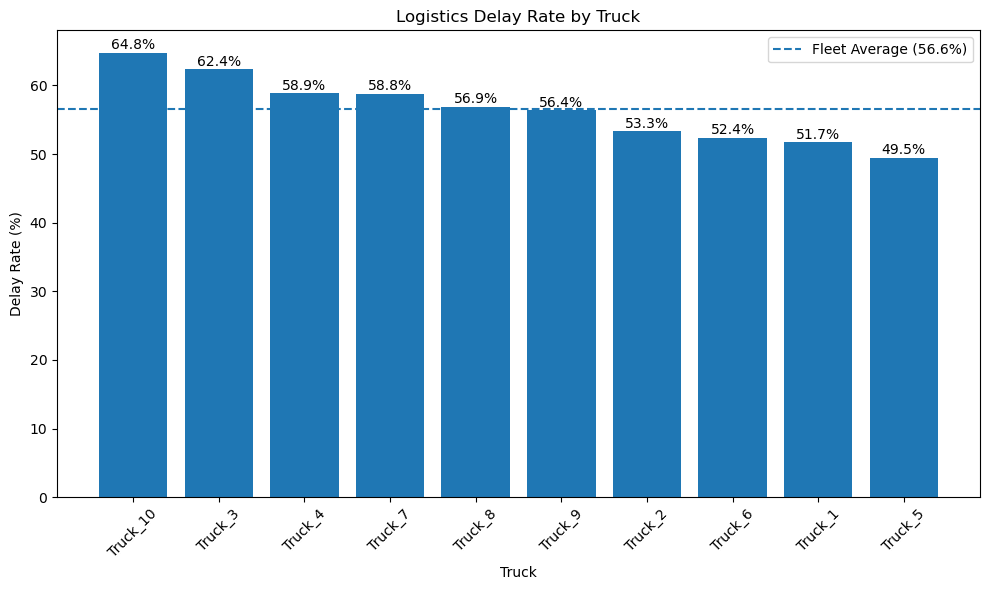

In [18]:
# Delay rate by truck

plt.figure(figsize=(10, 6))

bars = plt.bar(
    fleet_performance['Asset_ID'],
    fleet_performance['Delay_Rate']
)

plt.axhline(
    y=delay_rate,
    linestyle='--',
    label=f'Fleet Average ({delay_rate:.1f}%)'
)

plt.title('Logistics Delay Rate by Truck')
plt.xlabel('Truck')
plt.ylabel('Delay Rate (%)')
plt.xticks(rotation=45)

# Add delay rate labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center'
    )

plt.legend()
plt.tight_layout()
plt.show()

### Observation 
* Delay rates vary across the fleet, ranging from 49.5% for Truck_5 to 64.8% for Truck_10.
* Truck_10 and Truck_3 have the highest observed delay rates, both exceeding the overall fleet delay rate of 56.6%.
* However, Truck_10 does not exhibit unusually high average waiting time or asset utilization, suggesting that operating conditions may contribute to its higher delay rate.

### Going back to hypothesis of heavy traffic resulting in delay rate 
* Previous Findings: 

Heavy traffic → 327 observations → 327 delays → 100% delay rate.

In [19]:
# Is Truck_10 simply encountering more heavy traffic?

In [20]:
# Traffic conditions experienced by each truck

truck_traffic = pd.crosstab(
    data['Asset_ID'],
    data['Traffic_Status']
)

truck_traffic

Traffic_Status,Clear,Detour,Heavy
Asset_ID,,,
Truck_1,29,32,28
Truck_10,33,35,37
Truck_2,31,43,31
Truck_3,22,34,37
Truck_4,38,35,34
Truck_5,33,32,28
Truck_6,39,32,32
Truck_7,33,34,35
Truck_8,33,41,35


In [21]:
truck_traffic_pct = pd.crosstab(
    data['Asset_ID'],
    data['Traffic_Status'],
    normalize='index'
) * 100

truck_traffic_pct = truck_traffic_pct.round(1)

truck_traffic_pct

Traffic_Status,Clear,Detour,Heavy
Asset_ID,,,
Truck_1,32.6,36.0,31.5
Truck_10,31.4,33.3,35.2
Truck_2,29.5,41.0,29.5
Truck_3,23.7,36.6,39.8
Truck_4,35.5,32.7,31.8
Truck_5,35.5,34.4,30.1
Truck_6,37.9,31.1,31.1
Truck_7,32.4,33.3,34.3
Truck_8,30.3,37.6,32.1


### Observations 
Truck_3 has the highest encounter with heavy traffic 

Already established that heavy traffic has a 100% delay rate in this dataset. So truck_3's high 62.4% delay rate may partly reflect its operating environment rather than poor truck performance.
    
But truck_10 has the most delays and above avergae encounter with heavy traffic at 35.2 % which is above avergae but not extreme

### When traffic conditions are the same, do trucks still have different delay rates?

In [22]:
# Delay rate by truck and traffic condition

truck_traffic_delay = pd.pivot_table(
    data,
    values='Logistics_Delay',
    index='Asset_ID',
    columns='Traffic_Status',
    aggfunc='mean'
) * 100

truck_traffic_delay = truck_traffic_delay.round(1)

truck_traffic_delay

Traffic_Status,Clear,Detour,Heavy
Asset_ID,,,
Truck_1,34.5,25.0,100.0
Truck_10,39.4,51.4,100.0
Truck_2,38.7,30.2,100.0
Truck_3,45.5,32.4,100.0
Truck_4,39.5,40.0,100.0
Truck_5,24.2,31.2,100.0
Truck_6,23.1,40.6,100.0
Truck_7,33.3,41.2,100.0
Truck_8,42.4,31.7,100.0


### Observation 
* Was already expecting Heavy to be 100% for every truck.

  
* Truck_10: with clear traffic -> 50% delayed
While...
* Truck_5 under clear traffic → 25% delayed

### Analysis

* Truck_10's higher overall delay rate can't simply be explained by experiencing more heavy traffic.

* On the other hand, if their Clear/Detour delay rates are similar, we'd have evidence that traffic exposure is driving much of the apparent fleet difference.

In [23]:
# Overall delay rate for each traffic condition

traffic_delay_rate = (
    data.groupby('Traffic_Status')['Logistics_Delay']
    .mean()
    .mul(100)
    .round(1)
)

traffic_delay_rate

Traffic_Status
Clear      35.1
Detour     35.9
Heavy     100.0
Name: Logistics_Delay, dtype: float64

#### Observation: 

Traffic exposure varies across fleet assets. 

Clear and Detour Delay rate are both close to 35% - 36%, while Heavy traffic behaves completely differently.

Truck_3 has the highest proportion of heavy-traffic observations (39.8%), which may partially explain its elevated delay rate of 62.4%. 

Truck_10 also experiences above-average heavy-traffic exposure (35.2%) but has the highest overall delay rate (64.8%), suggesting that traffic exposure alone may not fully explain differences in fleet performance. 
Delay rates should therefore be compared across trucks while controlling for traffic conditions.

In [24]:
# Delay rate by truck under each traffic condition

truck_traffic_delay = pd.pivot_table(
    data,
    values='Logistics_Delay',
    index='Asset_ID',
    columns='Traffic_Status',
    aggfunc='mean'
) * 100

truck_traffic_delay = truck_traffic_delay.round(1)

truck_traffic_delay

Traffic_Status,Clear,Detour,Heavy
Asset_ID,,,
Truck_1,34.5,25.0,100.0
Truck_10,39.4,51.4,100.0
Truck_2,38.7,30.2,100.0
Truck_3,45.5,32.4,100.0
Truck_4,39.5,40.0,100.0
Truck_5,24.2,31.2,100.0
Truck_6,23.1,40.6,100.0
Truck_7,33.3,41.2,100.0
Truck_8,42.4,31.7,100.0


### Fleet Performance Analysis Conclusion 
So far we learned that Truck_10 has the highest overall delay rate (64.8%) and remains above the fleet benchmark under Clear and especially Detour conditions. Truck_3’s high delay rate appears partly related to its greater exposure to Heavy traffic. Most importantly, Heavy traffic produced a 100% delay rate for every truck.

## 3. Traffic Conditions and Logistics Delays

* Examine how traffic conditions are associated with logistics delays and if
traffic conditions also influence waiting time and other operational performance measures.

### Average waiting time by traffic condition

In [25]:
# Average waiting time by traffic condition

traffic_waiting = (
    data.groupby('Traffic_Status')['Waiting_Time']
    .agg(['count', 'mean', 'median', 'std'])
    .round(1)
)

traffic_waiting

,count,mean,median,std
Traffic_Status,,,,
Clear,328,35.5,35.0,14.9
Detour,345,35.3,35.0,13.8
Heavy,327,34.3,34.0,14.7


### Compare waiting-time distributions

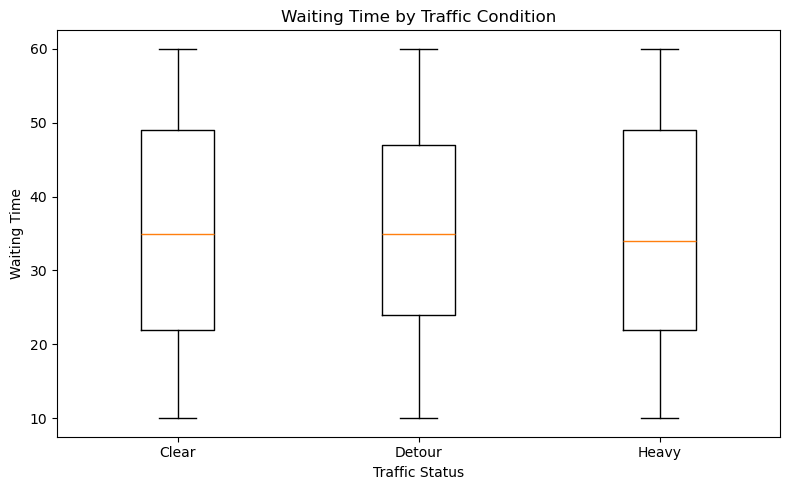

In [26]:
# Waiting time distribution by traffic condition

traffic_order = ['Clear', 'Detour', 'Heavy']

waiting_by_traffic = [
    data.loc[data['Traffic_Status'] == status, 'Waiting_Time']
    for status in traffic_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    waiting_by_traffic,
    tick_labels=traffic_order
)

plt.title('Waiting Time by Traffic Condition')
plt.xlabel('Traffic Status')
plt.ylabel('Waiting Time')

plt.tight_layout()
plt.show()

### Waiting time vs Delays

In [27]:
# Waiting time by delay status

waiting_delay = (
    data.groupby('Logistics_Delay')['Waiting_Time']
    .agg(['count', 'mean', 'median', 'std'])
    .round(1)
)

waiting_delay.index = ['No Delay', 'Delay']

waiting_delay

,count,mean,median,std
No Delay,434,36.1,36.0,14.2
Delay,566,34.3,34.0,14.7


### Visualize Wait time vs Delays

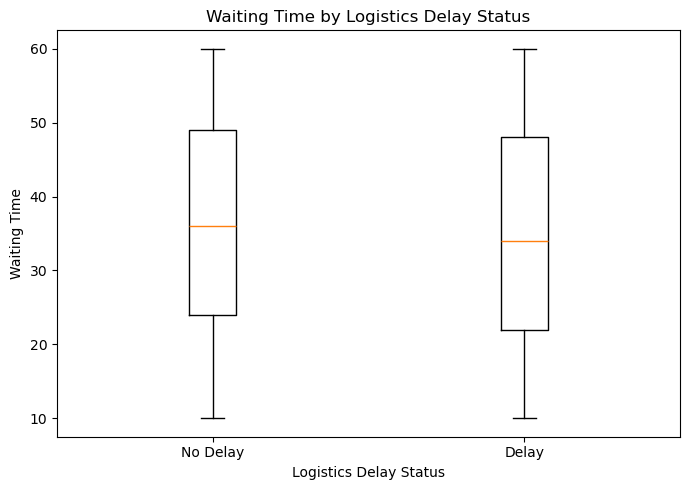

In [28]:
waiting_no_delay = data.loc[
    data['Logistics_Delay'] == 0,
    'Waiting_Time'
]

waiting_delay_values = data.loc[
    data['Logistics_Delay'] == 1,
    'Waiting_Time'
]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [waiting_no_delay, waiting_delay_values],
    tick_labels=['No Delay', 'Delay']
)

plt.title('Waiting Time by Logistics Delay Status')
plt.xlabel('Logistics Delay Status')
plt.ylabel('Waiting Time')

plt.tight_layout()
plt.show()

#### Observation: 

Waiting-time distributions are highly similar between delayed and non-delayed observations. 
Both groups have comparable medians, ranges, and interquartile ranges, 
suggesting that waiting time alone does not appear to be strongly associated with logistics delays.

#### Waiting time does not appear to explain logistics delays in this dataset.
* Both boxplots are almost the same

#### Hypothesis: Longer waiting times are associated with a greater likelihood of logistics delay.
    * Hypothesis is not supported by the boxplots 

### Asset Utilization
* Does higher fleet utilization correspond with increased logistics delays?

In [29]:
# compare utilization for delayed versus non-delayed observations

In [30]:
# Asset utilization by delay status

utilization_delay = (
    data.groupby('Logistics_Delay')['Asset_Utilization']
    .agg(['count', 'mean', 'median', 'std'])
    .round(1)
)

utilization_delay.index = ['No Delay', 'Delay']

utilization_delay

,count,mean,median,std
No Delay,434,79.6,80.0,11.5
Delay,566,79.6,79.0,11.7


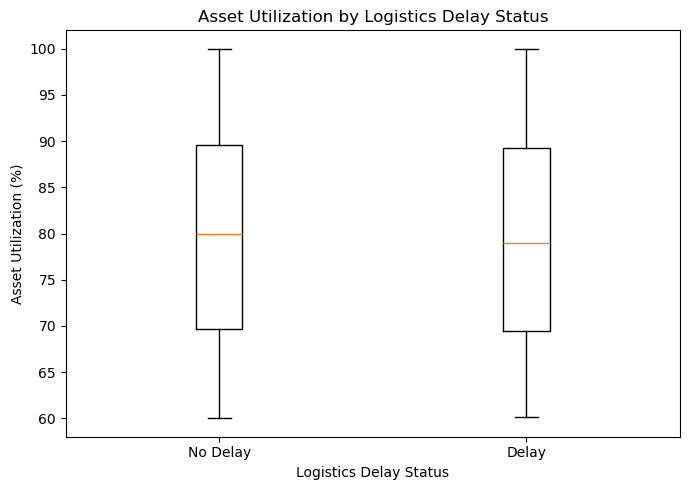

In [31]:
no_delay_utilization = data.loc[
    data['Logistics_Delay'] == 0,
    'Asset_Utilization'
]

delay_utilization = data.loc[
    data['Logistics_Delay'] == 1,
    'Asset_Utilization'
]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [no_delay_utilization, delay_utilization],
    tick_labels=['No Delay', 'Delay']
)

plt.title('Asset Utilization by Logistics Delay Status')
plt.xlabel('Logistics Delay Status')
plt.ylabel('Asset Utilization (%)')

plt.tight_layout()
plt.show()

In [32]:
# Create asset utilization groups

data['Utilization_Group'] = pd.cut(
    data['Asset_Utilization'],
    bins=[60, 70, 80, 90, 100],
    labels=['60-70%', '70-80%', '80-90%', '90-100%'],
    include_lowest=True
)

In [33]:
utilization_delay_rate = (
    data.groupby(
        'Utilization_Group',
        observed=True
    )['Logistics_Delay']
    .agg(['count', 'mean'])
)

utilization_delay_rate['Delay_Rate'] = (
    utilization_delay_rate['mean'] * 100
).round(1)

utilization_delay_rate

,count,mean,Delay_Rate
Utilization_Group,,,
60-70%,269,0.568773,56.9
70-80%,243,0.584362,58.4
80-90%,250,0.544000,54.4
90-100%,238,0.567227,56.7


#### Recall:  56.7% Overall Delay Rate

#### Observation
* Asset utilization does not show a clear relationship with logistics delays. 
* Delay rates remain relatively stable across utilization groups, ranging from 54.4% to 58.4%, and the utilization distributions for delayed and non-delayed observations substantially overlap.
* Higher asset utilization therefore does not appear to increase delay risk in this dataset.


### Inventory & Demand
* From the data cleaning phase:  261 out of 1000 observatoins have forecast demand greater than avaible inventory

In [34]:
# Check whether forecast demand exceeds available inventory
(data['Demand_Forecast'] > data['Inventory_Level']).value_counts()

False    739
True     261
Name: count, dtype: int64

## 4. Inventory and Demand Analysis

* Evaluate whether available inventory is sufficient to meet
forecast demand and if it identifies observations with potential inventory shortages.

#### Inventory gap

In [35]:
# Calculate inventory surplus or shortage

data['Inventory_Gap'] = (
    data['Inventory_Level'] - data['Demand_Forecast']
)

'''
Inventory_Gap > 0   -> inventory surplus

Inventory_Gap == 0  -> inventory exactly meets forecast demand

Inventory_Gap < 0   -> potential shortage
'''

In [36]:
data['Inventory_Gap'].describe()

count    1000.000000
mean       98.631000
std       129.278094
min      -185.000000
25%        -4.000000
50%        94.000000
75%       198.000000
max       391.000000
Name: Inventory_Gap, dtype: float64

In [37]:
# Observations with the largest potential inventory shortages (lowest 10 obersations of invetory_gap)

data.nsmallest(
    10,
    'Inventory_Gap'
)[
    [
        'Asset_ID',
        'Inventory_Level',
        'Demand_Forecast',
        'Inventory_Gap',
        'Logistics_Delay'
    ]
]

,Asset_ID,Inventory_Level,Demand_Forecast,Inventory_Gap,Logistics_Delay
325,Truck_10,105,290,-185,1
211,Truck_8,106,286,-180,0
906,Truck_10,113,293,-180,0
523,Truck_1,104,283,-179,0
109,Truck_4,100,274,-174,1
493,Truck_9,127,299,-172,1
545,Truck_4,106,276,-170,1
119,Truck_4,118,284,-166,1
904,Truck_3,121,286,-165,0
667,Truck_2,117,277,-160,1


#### Shortage indicator

In [38]:
data['Inventory_Shortage'] = (
    data['Inventory_Gap'] < 0
)

In [39]:
shortage_summary = data['Inventory_Shortage'].value_counts()

shortage_summary

Inventory_Shortage
False    739
True     261
Name: count, dtype: int64

#### Does inventory shortage relate to logistics delay?
* When inventory is insufficient to meet forecast demand, are delays more common?

In [40]:
pd.crosstab(
    data['Inventory_Shortage'],
    data['Logistics_Delay'],
    normalize='index'
).round(3) * 100

Logistics_Delay,0,1
Inventory_Shortage,,
False,43.7,56.3
True,42.5,57.5


#### Visualize inventory versus demand

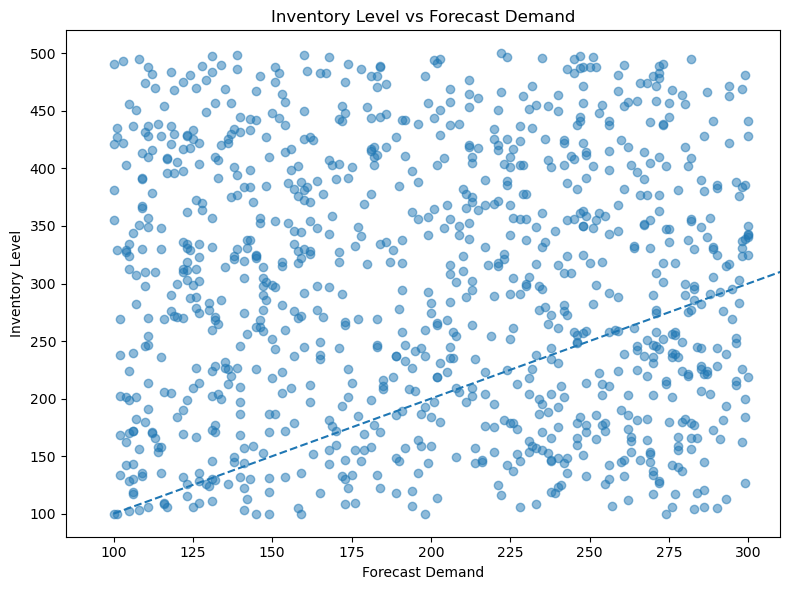

In [41]:
plt.figure(figsize=(8, 6))

plt.scatter(
    data['Demand_Forecast'],
    data['Inventory_Level'],
    alpha=0.5
)

# Reference line where inventory equals demand
minimum = min(
    data['Demand_Forecast'].min(),
    data['Inventory_Level'].min()
)

maximum = max(
    data['Demand_Forecast'].max(),
    data['Inventory_Level'].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle='--'
)

plt.xlim(85,310)

plt.title('Inventory Level vs Forecast Demand')
plt.xlabel('Forecast Demand')
plt.ylabel('Inventory Level')

plt.tight_layout()
plt.show()

#### Observation: 
* Most observations have inventory levels sufficient to meet forecast demand 
* However, 261 observations (26.1%) have forecast demand exceeding available inventory, indicating potential inventory shortages.
* The scatterplot also shows no clear linear relationship between inventory levels and forecast demand, suggesting that inventory levels may not be closely aligned with expected demand.

#### shortage vs. logistics delay

In [42]:
pd.crosstab(
    data['Inventory_Shortage'],
    data['Logistics_Delay'],
    normalize='index'
).round(3) * 100

Logistics_Delay,0,1
Inventory_Shortage,,
False,43.7,56.3
True,42.5,57.5


 Inventory shortage does not appear to meaningfully affect delay risk
Observations without an inventory shortage have a 56.3% delay rate, compared with 57.5% among observations with a shortage.


#### Observation: 
* Potential inventory shortages show little association with logistics delays.
* Observations without an inventory shortage have a 56.3% delay rate, compared with 57.5% among observations with a shortage.
* The small difference suggests that inventory shortage is unlikely to be a major predictor of logistics delays in this dataset.
* However, inventory shortages remain operationally important and may be useful in the later optimization analysis.

### Temporal Analysis
* Do logistics delays vary by month, day of week, or hour of day?

In [43]:
# Extract time-based features

data['Month'] = data['Timestamp'].dt.month
data['Month_Name'] = data['Timestamp'].dt.month_name()

data['Day_of_Week'] = data['Timestamp'].dt.day_name()

data['Hour'] = data['Timestamp'].dt.hour

data['Is_Weekend'] = data['Timestamp'].dt.dayofweek >= 5

In [44]:
# monthly delay rate

In [45]:
monthly_delay = (
    data.groupby('Month')['Logistics_Delay']
    .agg(['count', 'mean'])
)

monthly_delay['Delay_Rate'] = (
    monthly_delay['mean'] * 100
).round(1)

monthly_delay

,count,mean,Delay_Rate
Month,,,
1,92,0.521739,52.2
2,77,0.610390,61.0
3,94,0.563830,56.4
4,86,0.569767,57.0
5,74,0.527027,52.7
6,77,0.662338,66.2
7,86,0.627907,62.8
8,77,0.584416,58.4
9,83,0.481928,48.2


A better hypothesis:
Does June simply contain a larger proportion of Heavy traffic observations?

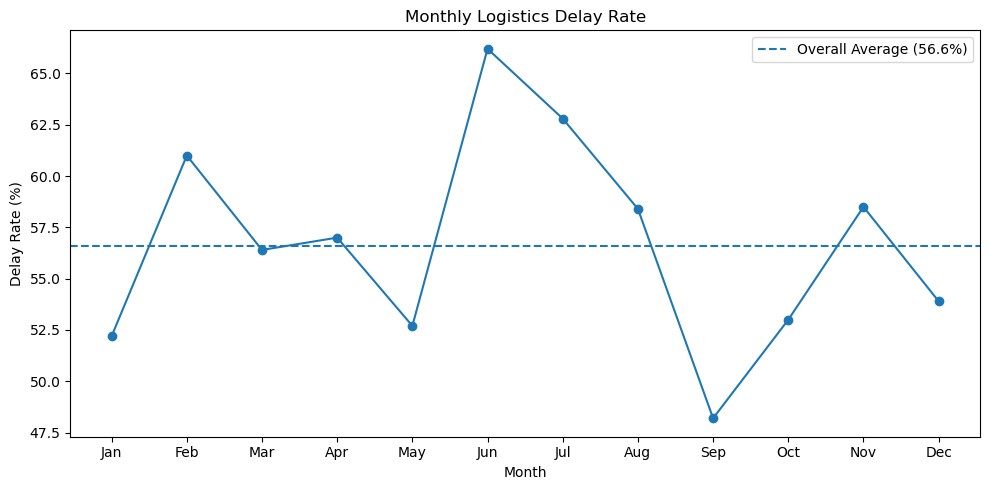

In [46]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_delay.index,
    monthly_delay['Delay_Rate'],
    marker='o'
)

plt.axhline(
    y=delay_rate,
    linestyle='--',
    label=f'Overall Average ({delay_rate:.1f}%)'
)

plt.title('Monthly Logistics Delay Rate')
plt.xlabel('Month')
plt.ylabel('Delay Rate (%)')

plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

plt.legend()
plt.tight_layout()
plt.show()

In [47]:
monthly_traffic = pd.crosstab(
    data['Month'],
    data['Traffic_Status'],
    normalize='index'
) * 100

monthly_traffic = monthly_traffic.round(1)

monthly_traffic

Traffic_Status,Clear,Detour,Heavy
Month,,,
1,34.8,35.9,29.3
2,29.9,35.1,35.1
3,35.1,33.0,31.9
4,32.6,29.1,38.4
5,39.2,35.1,25.7
6,32.5,28.6,39.0
7,33.7,37.2,29.1
8,33.8,31.2,35.1
9,37.3,28.9,33.7


In [48]:
# Remove Heavy Traffic from equation

non_heavy = data[
    data['Traffic_Status'] != 'Heavy'
]

monthly_delay_non_heavy = (
    non_heavy.groupby('Month')['Logistics_Delay']
    .mean()
    .mul(100)
    .round(1)
)

monthly_delay_non_heavy

Month
1     32.3
2     40.0
3     35.9
4     30.2
5     36.4
6     44.7
7     47.5
8     36.0
9     21.8
10    27.8
11    32.0
12    40.6
Name: Logistics_Delay, dtype: float64

- Traffic explains part of the problem and monthly differences but not all of them/


#### Day-of-week analysis

In [49]:
# Delay rate by day of week

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

daily_delay = (
    data.groupby('Day_of_Week')['Logistics_Delay']
    .agg(['count', 'mean'])
    .reindex(day_order)
)

daily_delay['Delay_Rate'] = (
    daily_delay['mean'] * 100
).round(1)

daily_delay

,count,mean,Delay_Rate
Day_of_Week,,,
Monday,153,0.522876,52.3
Tuesday,140,0.650000,65.0
Wednesday,158,0.563291,56.3
Thursday,135,0.555556,55.6
Friday,147,0.537415,53.7
Saturday,139,0.597122,59.7
Sunday,128,0.539062,53.9


- Tuesday stands out ^

#### Does Tuesday simply have more Heavy traffic?

In [50]:
# Traffic conditions by day of week

daily_traffic = pd.crosstab(
    data['Day_of_Week'],
    data['Traffic_Status'],
    normalize='index'
) * 100

daily_traffic = daily_traffic.reindex(day_order).round(1)

daily_traffic

Traffic_Status,Clear,Detour,Heavy
Day_of_Week,,,
Monday,32.7,37.9,29.4
Tuesday,32.1,30.0,37.9
Wednesday,30.4,32.3,37.3
Thursday,35.6,31.9,32.6
Friday,29.3,40.8,29.9
Saturday,36.7,30.9,32.4
Sunday,33.6,37.5,28.9


In [51]:
# Daily delay rates without  Heavy traffic

non_heavy = data[
    data['Traffic_Status'] != 'Heavy'
]

daily_delay_non_heavy = (
    non_heavy.groupby('Day_of_Week')['Logistics_Delay']
    .mean()
    .mul(100)
    .reindex(day_order)
    .round(1)
)

daily_delay_non_heavy

Day_of_Week
Monday       32.4
Tuesday      43.7
Wednesday    30.3
Thursday     34.1
Friday       34.0
Saturday     40.4
Sunday       35.2
Name: Logistics_Delay, dtype: float64

- Tuesday is still the highest 

### Geographic Analysis

This section examines the geographic distribution of logistics observations
and evaluates if location appears to be associated with logistics delays.

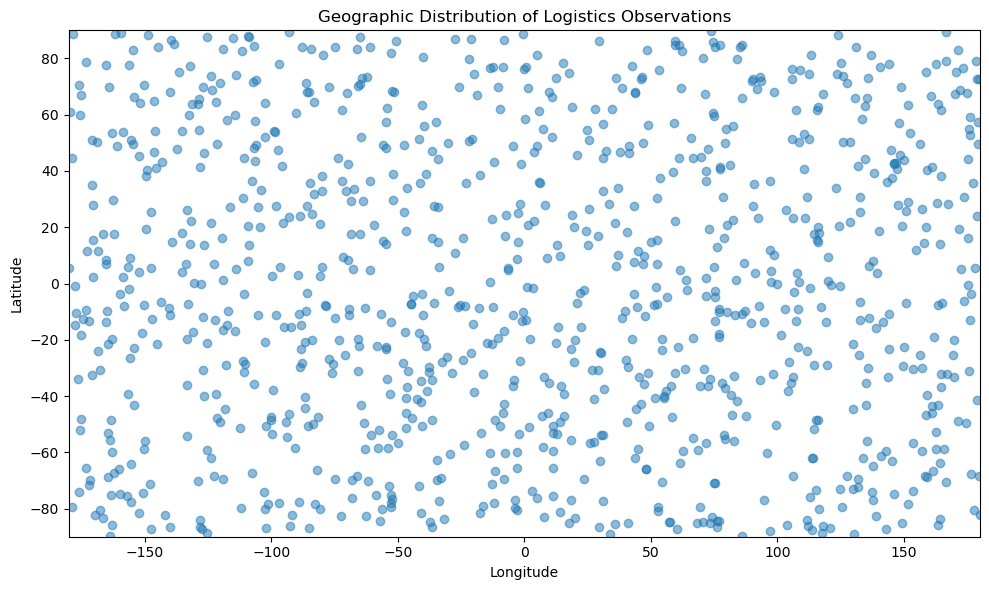

In [52]:
# Plot all locations

plt.figure(figsize=(10, 6))

plt.scatter(
    data['Longitude'],
    data['Latitude'],
    alpha=0.5
)

plt.title('Geographic Distribution of Logistics Observations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.tight_layout()
plt.show()

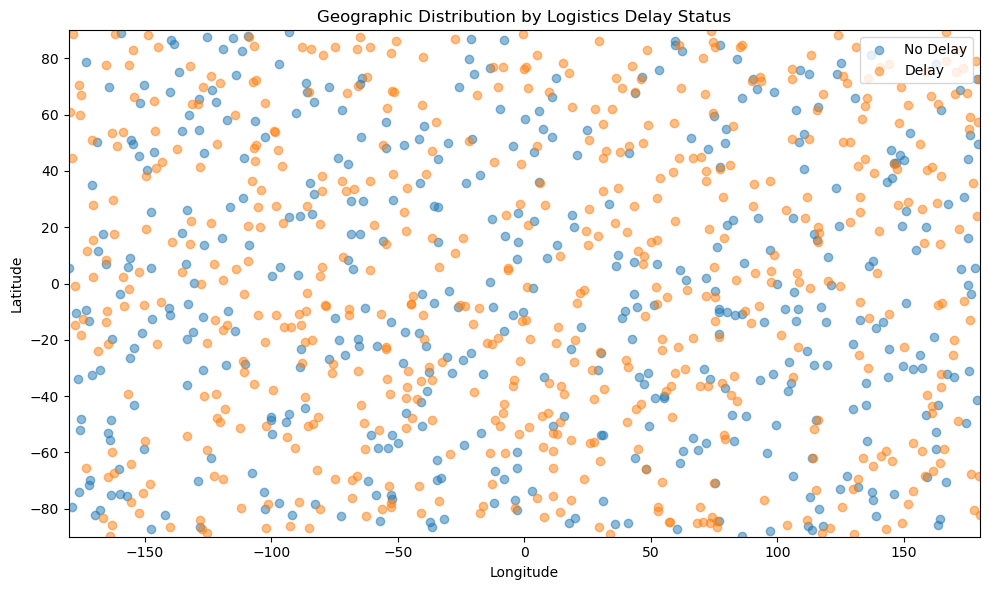

In [53]:
# Geographic distribution by delay status

no_delay = data[data['Logistics_Delay'] == 0]
delayed = data[data['Logistics_Delay'] == 1]

plt.figure(figsize=(10, 6))

plt.scatter(
    no_delay['Longitude'],
    no_delay['Latitude'],
    alpha=0.5,
    label='No Delay'
)

plt.scatter(
    delayed['Longitude'],
    delayed['Latitude'],
    alpha=0.5,
    label='Delay'
)

plt.title('Geographic Distribution by Logistics Delay Status')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.legend(loc= 'upper right')
plt.tight_layout()
plt.show()

#### Separate Delay vs. No Delay

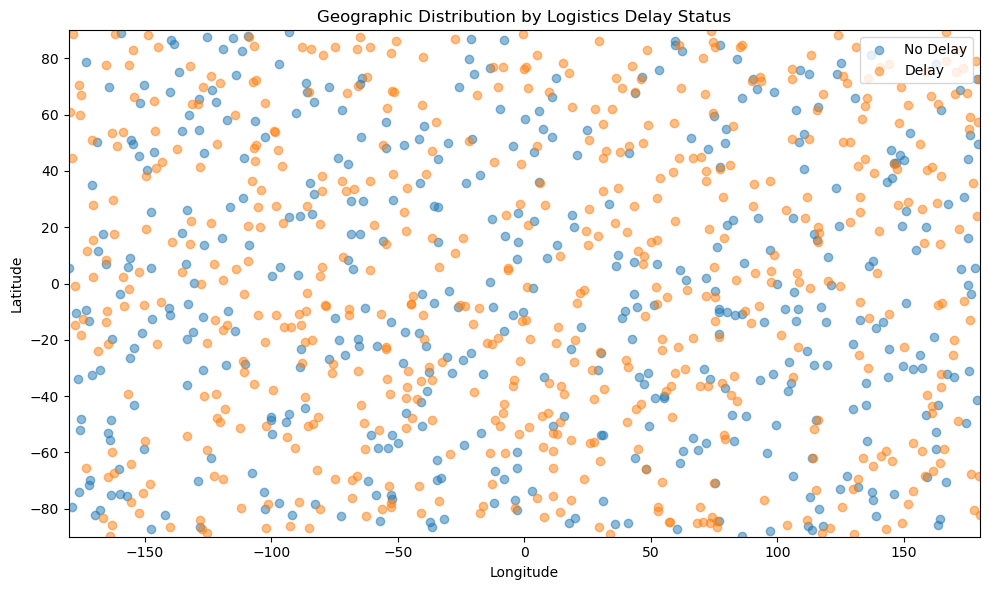

In [54]:
# Geographic distribution by delay status

no_delay = data[data['Logistics_Delay'] == 0]
delayed = data[data['Logistics_Delay'] == 1]

plt.figure(figsize=(10, 6))

plt.scatter(
    no_delay['Longitude'],
    no_delay['Latitude'],
    alpha=0.5,
    label='No Delay'
)

plt.scatter(
    delayed['Longitude'],
    delayed['Latitude'],
    alpha=0.5,
    label='Delay'
)

plt.title('Geographic Distribution by Logistics Delay Status')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.legend(loc= 'upper right')
plt.tight_layout()
plt.show()

#### Observation: 
- Geographic observations are broadly dispersed across nearly the full range of global latitude and longitude values. 
- Delayed and non-delayed observations are heavily intermixed, with no clear geographic clustering associated with logistics delays.
- Given the nature of this distribution, we can interpret the data to be generated rather than real true data.


### Feature Relationships
- Which numerical variables show the strongest relationships with Logistics_Delay?

Numerical correlation:

In [55]:
# Select Numerical variables to use for  correlation analysis

correlation_columns = [
    'Inventory_Level',
    'Temperature',
    'Humidity',
    'Waiting_Time',
    'User_Transaction_Amount',
    'User_Purchase_Frequency',
    'Asset_Utilization',
    'Demand_Forecast',
    'Inventory_Gap',
    'Logistics_Delay'
]

correlation_matrix = data[correlation_columns].corr()

correlation_matrix.round(2)

,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Inventory_Gap,Logistics_Delay
Inventory_Level,1.00,-0.02,0.01,-0.02,-0.04,-0.02,0.02,-0.02,0.89,-0.00
Temperature,-0.02,1.00,-0.02,0.02,-0.01,-0.02,0.05,-0.01,-0.01,-0.04
Humidity,0.01,-0.02,1.00,0.03,-0.03,0.02,-0.03,-0.01,0.01,-0.00
Waiting_Time,-0.02,0.02,0.03,1.00,-0.02,0.02,0.02,-0.03,-0.00,-0.06
User_Transaction_Amount,-0.04,-0.01,-0.03,-0.02,1.00,0.04,0.04,0.00,-0.03,0.01
User_Purchase_Frequency,-0.02,-0.02,0.02,0.02,0.04,1.00,0.02,-0.08,0.02,-0.02
Asset_Utilization,0.02,0.05,-0.03,0.02,0.04,0.02,1.00,-0.08,0.05,-0.00
Demand_Forecast,-0.02,-0.01,-0.01,-0.03,0.00,-0.08,-0.08,1.00,-0.48,-0.02
Inventory_Gap,0.89,-0.01,0.01,-0.00,-0.03,0.02,0.05,-0.48,1.00,0.01
Logistics_Delay,-0.00,-0.04,-0.00,-0.06,0.01,-0.02,-0.00,-0.02,0.01,1.00


In [56]:
# Correlation with logistics delay

delay_correlations = (
    correlation_matrix['Logistics_Delay']
    .drop('Logistics_Delay')
    .sort_values(key=abs, ascending=False)
)

delay_correlations

Waiting_Time              -0.063036
Temperature               -0.038067
Demand_Forecast           -0.018621
User_Purchase_Frequency   -0.017439
User_Transaction_Amount    0.013605
Inventory_Gap              0.005697
Inventory_Level           -0.003340
Asset_Utilization         -0.003140
Humidity                  -0.000504
Name: Logistics_Delay, dtype: float64

In [57]:
# strongest negative correlation Waiting_Time

Categorical Analysis

In [58]:
# Delay rate by traffic status
traffic_summary = (
    data.groupby('Traffic_Status')['Logistics_Delay']
    .agg(['count', 'mean'])
)

traffic_summary['Delay_Rate'] = (
    traffic_summary['mean'] * 100
).round(1)

traffic_summary

,count,mean,Delay_Rate
Traffic_Status,,,
Clear,328,0.35061,35.1
Detour,345,0.35942,35.9
Heavy,327,1.00000,100.0


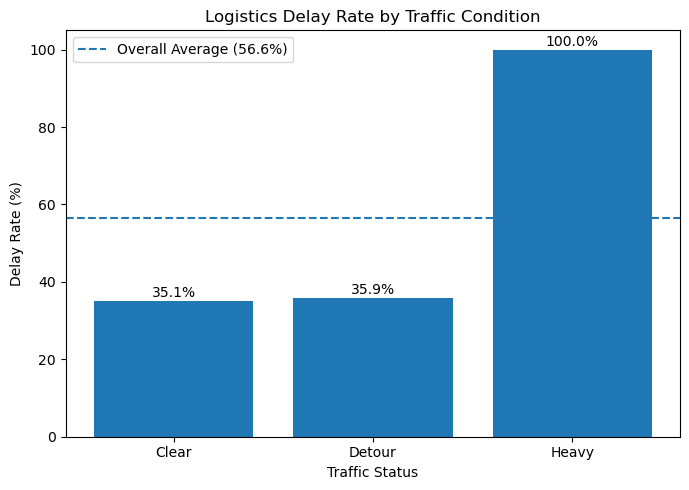

In [59]:
traffic_plot = (
    traffic_summary
    .sort_values('Delay_Rate')
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    traffic_plot.index,
    traffic_plot['Delay_Rate']
)

plt.axhline(
    y=delay_rate,
    linestyle='--',
    label=f'Overall Average ({delay_rate:.1f}%)'
)

plt.title('Logistics Delay Rate by Traffic Condition')
plt.xlabel('Traffic Status')
plt.ylabel('Delay Rate (%)')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center'
    )

plt.legend()
plt.tight_layout()
plt.show()

### EDA Summary

#### Findings:

- The dataset contains 1,000 logistics observations, of which 56.6% experienced a delay.
- Traffic conditions show the strongest observed relationship with logistics delays. All observations recorded under Heavy traffic resulted in a delay, while Clear and Detour conditions had delay rates of approximately 35%.
- Delay rates vary somewhat across trucks, months, and days of the week, but part of the variation is associated with differences in traffic levels.
- Waiting time, asset utilization, inventory levels, forecast demand, environmental measurements, and customer variables show little apparent linear relationship with logistics delays.
- Potential inventory shortages occur in 26.1% of observations but show little association with logistics delay. These shortages remain relevant for later optimization analysis.
- Latitude and longitude values are broadly distributed across the globe and do not reveal meaningful geographic clustering.
- Several characteristics—including globally dispersed coordinates and deterministic Heavy-traffic delays—suggest that the dataset may be synthetic.
* Results should therefore be interpreted as a demonstration of analytical methodology rather than evidence about a real logistics operation.

#### Modeling Considerations: 
- Shipment_Status should be excluded from delay prediction because the Delayed category directly reveals the target and would introduce target leakage.
- Logistics_Delay_Reason should also be excluded because the reason for a delay would generally not be known at the time a prediction is made. Geographic variables may be tested but should be treated cautiously due to their apparently synthetic distribution